In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer
import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd

import json

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: cuda


In [2]:
from torchvision import datasets, transforms
from experiments.datasets.all_datasets import MNISTDataset

mnist = MNISTDataset()
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [3]:
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = 28*28
hidden_layers = [32,32,632]
output_size = 10

base_model = MLP(input_dim, hidden_layers, output_size)
base_params = copy.deepcopy(base_model.state_dict())
del base_model

# train normal supervised model

In [4]:
model_sup = MLP(input_dim, hidden_layers, output_size)
model_sup.load_state_dict(base_params)
model_sup.to(device)
optimizer = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
losses_direct = defaultdict(list)
for epoch in tqdm(range(num_epochs)):
    epoch_losses = defaultdict(list)
    model_sup.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
        acc = (ypred.argmax(dim=1) == yb).sum().item()
        total = yb.size(0)
        epoch_losses['train_acc'].append(acc / total)
    model_sup.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = model_sup(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
            correct = (ypred.argmax(dim=1) == yb).sum().item()
            total = yb.size(0)
            epoch_losses['val_acc'].append(correct / total)
    # Save batch-wise losses
    losses_direct['train_batch'].extend(epoch_losses['train'])
    losses_direct['val_batch'].extend(epoch_losses['val'])
    # Save epoch-averaged losses
    for k,v in epoch_losses.items():
        losses_direct[k].append(np.mean(v))

100%|██████████| 20/20 [00:24<00:00,  1.21s/it]


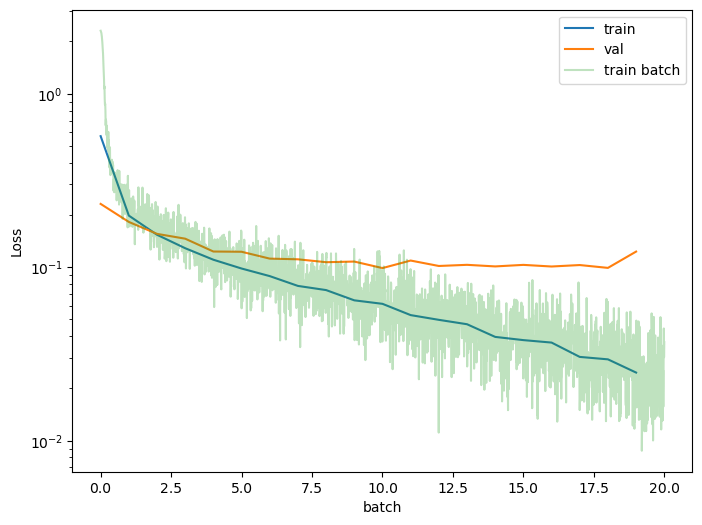

In [5]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='train')
plt.plot(losses_direct['val'], label='val')
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
plt.plot(xvals, losses_direct['train_batch'], label='train batch', alpha=0.3)
plt.xlabel('batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

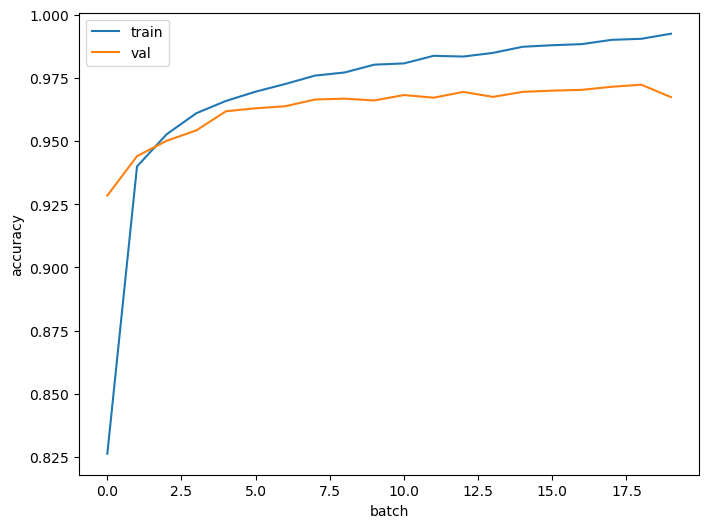

In [6]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_acc'], label='train')
plt.plot(losses_direct['val_acc'], label='val')
plt.xlabel('batch')
plt.ylabel('accuracy')
#plt.yscale('log')
plt.legend()
plt.show()

# svd loss (new framework)

In [ ]:
mlp_svd = MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size).to(device)
loss_fn = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

num_epochs = 5

lr_svd = 0.1
k_svd = batch_size
rtol = 1e-3 
model_svd = FunctionalModelJac(mlp_svd, loss_lambda, device)
opt_svd = SVDOptimizer(model_svd, lr=lr_svd, k=k_svd, rtol=rtol, track_svd_info=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

losses_svd = defaultdict(list)

# save untrained validation loss
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = model_svd.evaluate(xb)
        loss = loss_lambda(ypred, yb).mean()
        losses_svd['val_init'].append(loss.item())

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses, ypred = model_svd.loss_and_grad(batch)
            opt_svd.step()
            epoch_losses['train'].append(losses.mean().item())
            acc = (ypred.argmax(dim=1) == yb).sum().item()
            total = yb.size(0)
            epoch_losses['train_acc'].append(acc / total)
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = model_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
            acc = (ypred.argmax(dim=1) == yb).sum().item()
            total = yb.size(0)
            epoch_losses['val_acc'].append(acc / total)
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))
torch.compiler.reset()
#with open("mnist_svd_losses.pt", "w") as f:
#    json.dump(losses_svd, f)

Epoch 1/5


100%|██████████| 117/117 [00:24<00:00,  4.70it/s]


Epoch 2/5


100%|██████████| 117/117 [00:19<00:00,  6.00it/s]


Epoch 3/5


100%|██████████| 117/117 [00:17<00:00,  6.73it/s]


Epoch 4/5


100%|██████████| 117/117 [00:17<00:00,  6.77it/s]


Epoch 5/5


100%|██████████| 117/117 [00:15<00:00,  7.56it/s]


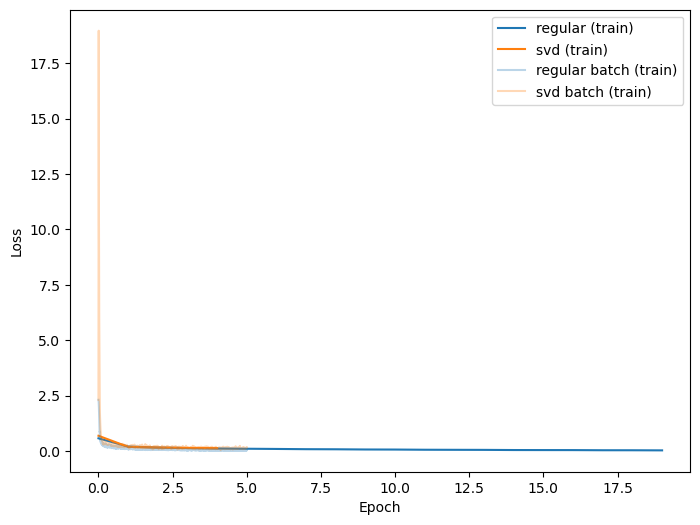

In [19]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='regular (train)',color="C0")
plt.plot(losses_svd['train'], label='svd (train)',color="C1")
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
xvals_svd = np.linspace(0,num_epochs,len(losses_svd['train_batch']))    
plt.plot(xvals, losses_direct['train_batch'], label='regular batch (train)', alpha=0.3)
plt.plot(xvals_svd, losses_svd['train_batch'], label='svd batch (train)', alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.legend()
plt.show()

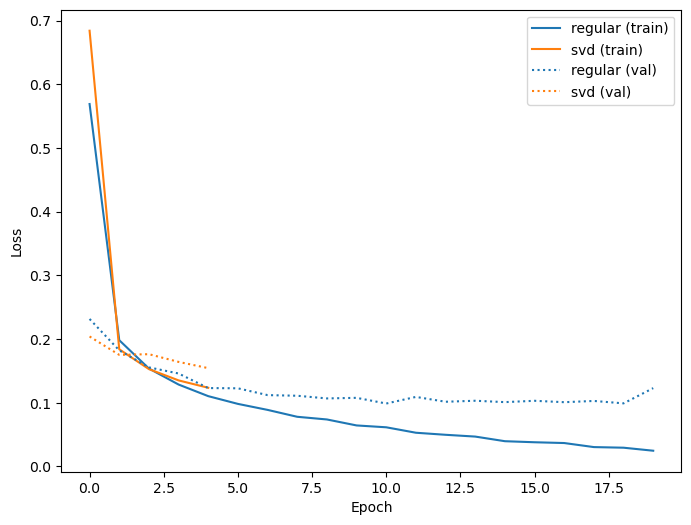

In [20]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='regular (train)',color="C0")
plt.plot(losses_svd['train'], label='svd (train)',color="C1")
plt.plot(losses_direct['val'], label='regular (val)',color="C0",linestyle=':')
plt.plot(losses_svd['val'], label='svd (val)',color="C1",linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.legend()
plt.show()

(0.1, 27.856919584430436)

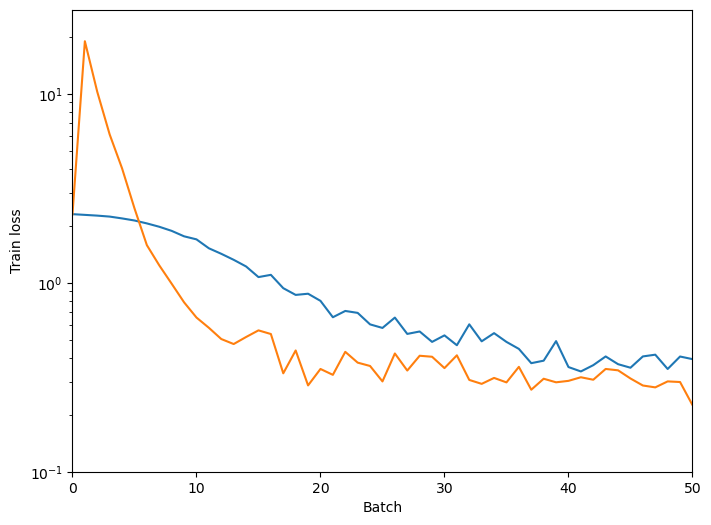

In [22]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_batch'], label='regular (train)')
plt.plot(losses_svd['train_batch'], label='svd (train)')
plt.xlabel('Batch')
plt.ylabel('Train loss')
plt.yscale('log')
plt.xlim([0,50])
plt.ylim([1e-1,None])

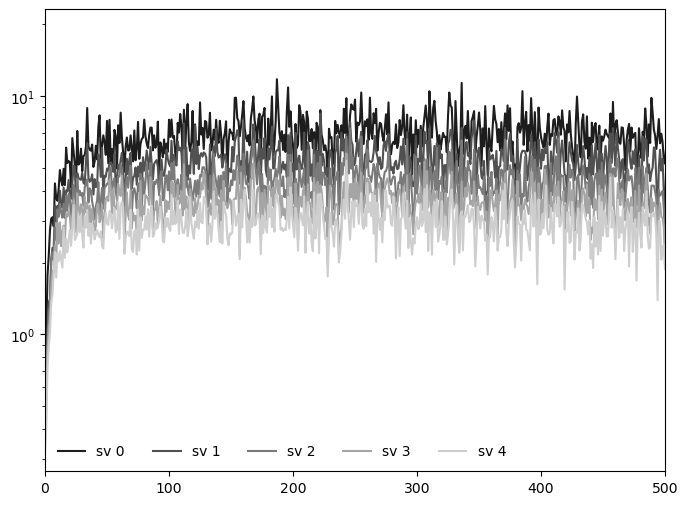

In [57]:
plt.figure(figsize=(8,6))
n_track = 5
colors = plt.cm.Grays(np.linspace(0.3, 0.9, n_track))[::-1]
for i in range(n_track):
    yvals = [v[i] for v in opt_svd.svd_info['svs']]
    plt.plot(yvals, label=f"sv {i}", color=colors[i])
plt.xlim([0,500])
plt.yscale('log')
plt.legend(loc='lower left',ncol=6,frameon=False)

# timing test

In [13]:
import time
import numpy as np

def _device_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.synchronize()

def time_svd_epoch(fmodel_svd, opt_svd, params_svd, train_loader, max_batches=None):
    stats = {"jacobian": [], "update": [], "apply": [], "pinv_total": []}
    import torch_svd as tsvd
    last_pinv_time = {"total": None}
    _orig_pinv = tsvd.pinv
    def _timed_pinv(*args, **kwargs):
        _device_sync()
        t0 = time.perf_counter()
        out = _orig_pinv(*args, **kwargs)
        _device_sync()
        elapsed = time.perf_counter() - t0
        last_pinv_time["total"] = elapsed
        return out
    tsvd.pinv = _timed_pinv
    def _record(name, val):
        stats[name].append(val)
    batch_iter = enumerate(train_loader)
    if max_batches is None:
        max_batches = len(train_loader)
    for bi, (xb, yb) in batch_iter:
        if bi >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        batch = (xb, yb)
        _device_sync()
        t0 = time.perf_counter()
        gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
        _device_sync()
        jac_t = time.perf_counter() - t0
        _record("jacobian", jac_t)
        _device_sync()
        t0 = time.perf_counter()
        update = opt_svd.compute_update(gradients, losses)
        _device_sync()
        upd_t = time.perf_counter() - t0
        _record("update", upd_t)
        if last_pinv_time["total"] is not None:
            _record("pinv_total", last_pinv_time["total"])
            last_pinv_time["total"] = None
        _device_sync()
        t0 = time.perf_counter()
        params_svd = params_svd + update
        fmodel_svd.params = params_svd
        _device_sync()
        app_t = time.perf_counter() - t0
        _record("apply", app_t)
    tsvd.pinv = _orig_pinv
    def _summ(d):
        a = np.array(d) if len(d) else np.array([0.0])
        return dict(mean=a.mean(), std=a.std(), min=a.min(), max=a.max(), count=len(a))
    summary = {k: _summ(v) for k, v in stats.items()}
    total = sum(summary[k]["mean"] for k in ("jacobian", "update", "apply") if summary[k]["count"] > 0)
    pct = {k: (summary[k]["mean"] / total * 100.0 if total > 0 else 0.0) for k in ("jacobian", "update", "apply")}
    return summary, pct, params_svd

def time_normal_epoch(model, optimizer, loss_fn, train_loader, max_batches=None):
    stats = {"forward": [], "backward": [], "step": []}
    batch_iter = enumerate(train_loader)
    if max_batches is None:
        max_batches = len(train_loader)
    for bi, (xb, yb) in batch_iter:
        if bi >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        _device_sync()
        t0 = time.perf_counter()
        ypred = model(xb)
        loss = loss_fn(ypred, yb)
        _device_sync()
        fwd_t = time.perf_counter() - t0
        stats["forward"].append(fwd_t)
        _device_sync()
        t0 = time.perf_counter()
        loss.backward()
        _device_sync()
        bwd_t = time.perf_counter() - t0
        stats["backward"].append(bwd_t)
        _device_sync()
        t0 = time.perf_counter()
        optimizer.step()
        _device_sync()
        step_t = time.perf_counter() - t0
        stats["step"].append(step_t)
    def _summ(d):
        a = np.array(d) if len(d) else np.array([0.0])
        return dict(mean=a.mean(), std=a.std(), min=a.min(), max=a.max(), count=len(a))
    summary = {k: _summ(v) for k, v in stats.items()}
    total = sum(summary[k]["mean"] for k in ("forward", "backward", "step") if summary[k]["count"] > 0)
    pct = {k: (summary[k]["mean"] / total * 100.0 if total > 0 else 0.0) for k in ("forward", "backward", "step")}
    return summary, pct

def run_size_scaling_experiment(sizes, train_loader, test_loader):
    results = []
    for h in sizes:
        print(f"\nProfiling model with hidden size {h}")
        # Normal training
        model_sup = tsvd.MLP(input_dim, [h]*3, output_size).to(device)
        optimizer = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
        loss_fn = nn.CrossEntropyLoss()
        # SVD training
        model_svd = tsvd.MLP(input_dim, [h]*3, output_size).to(device)
        loss_fn_svd = nn.CrossEntropyLoss(reduction='none')
        loss_lambda = lambda pred, y: loss_fn_svd(pred, y).squeeze()
        fmodel_svd = tsvd.FunctionalModel(model_svd, loss_lambda)
        params_svd = fmodel_svd.params
        opt_svd = tsvd.SVDOptimizer(lr=0.5, k=min(150, h*3), rtol=1e-3)
        # Warmup
        xb, yb = next(iter(train_loader))
        xb, yb = xb.to(device), yb.to(device)
        _ = fmodel_svd.batch_gradient(params_svd, (xb, yb))
        _ = opt_svd.compute_update(*_)
        # Profile
        normal_summary, normal_pct = time_normal_epoch(model_sup, optimizer, loss_fn, train_loader, max_batches=10)
        svd_summary, svd_pct, _ = time_svd_epoch(fmodel_svd, opt_svd, params_svd, train_loader, max_batches=10)
        results.append({
            "hidden_size": h,
            "normal": normal_summary,
            "normal_pct": normal_pct,
            "svd": svd_summary,
            "svd_pct": svd_pct,
            "num_params": sum(p.numel() for p in model_sup.parameters())
        })
    return results

# Example usage:
hidden_sizes = [32, 64, 128, 256, 256, 512, 102esults = run_size_scaling_experiment(hidden_sizes, train_loader, test_loader)

# Print results
"""for res in results:
    h = res["hidden_size"]
    print(f"\nModel size: {h}")
    print("Normal training (mean times, sec):")
    for k, v in res["normal"].items():
        print(f"  {k:10s}: {v['mean']:.4f}")
    print("Normal breakdown (%):")
    for k, v in res["normal_pct"].items():
        print(f"  {k:10s}: {v:5.1f}%")
    print("SVD training (mean times, sec):")
    for k, v in res["svd"].items():
        print(f"  {k:10s}: {v['mean']:.4f}")
    print("SVD breakdown (%):")
    for k, v in res["svd_pct"].items():
        print(f"  {k:10s}: {v:5.1f}%")"""



Profiling model with hidden size 64

Profiling model with hidden size 128

Profiling model with hidden size 128

Profiling model with hidden size 256

Profiling model with hidden size 256

Profiling model with hidden size 512

Profiling model with hidden size 512

Profiling model with hidden size 1024

Profiling model with hidden size 1024



Profiling model with hidden size 64

Profiling model with hidden size 128

Profiling model with hidden size 128

Profiling model with hidden size 256

Profiling model with hidden size 256

Profiling model with hidden size 512

Profiling model with hidden size 512

Profiling model with hidden size 1024

Profiling model with hidden size 1024


'for res in results:\n    h = res["hidden_size"]\n    print(f"\nModel size: {h}")\n    print("Normal training (mean times, sec):")\n    for k, v in res["normal"].items():\n        print(f"  {k:10s}: {v[\'mean\']:.4f}")\n    print("Normal breakdown (%):")\n    for k, v in res["normal_pct"].items():\n        print(f"  {k:10s}: {v:5.1f}%")\n    print("SVD training (mean times, sec):")\n    for k, v in res["svd"].items():\n        print(f"  {k:10s}: {v[\'mean\']:.4f}")\n    print("SVD breakdown (%):")\n    for k, v in res["svd_pct"].items():\n        print(f"  {k:10s}: {v:5.1f}%")'

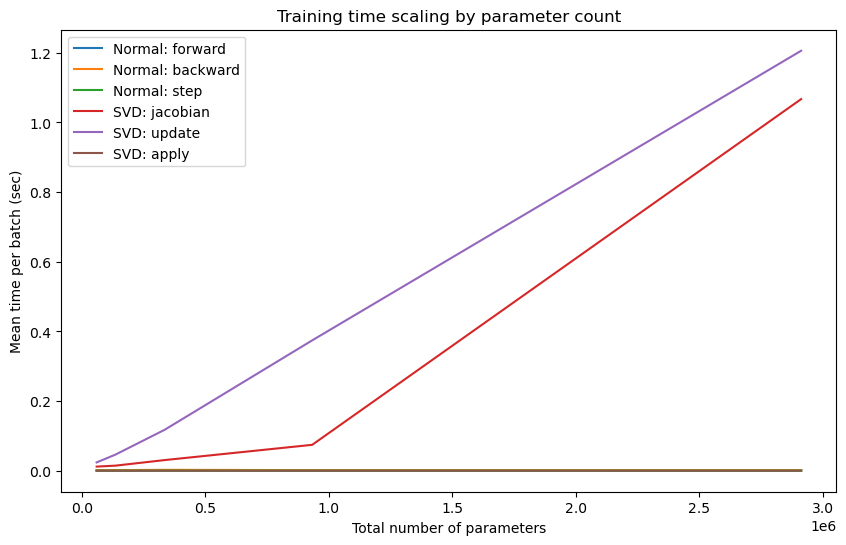

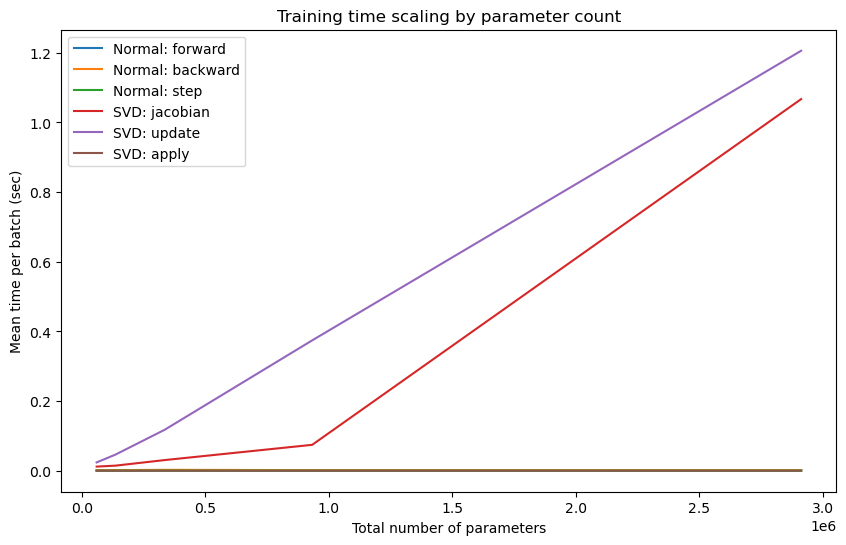

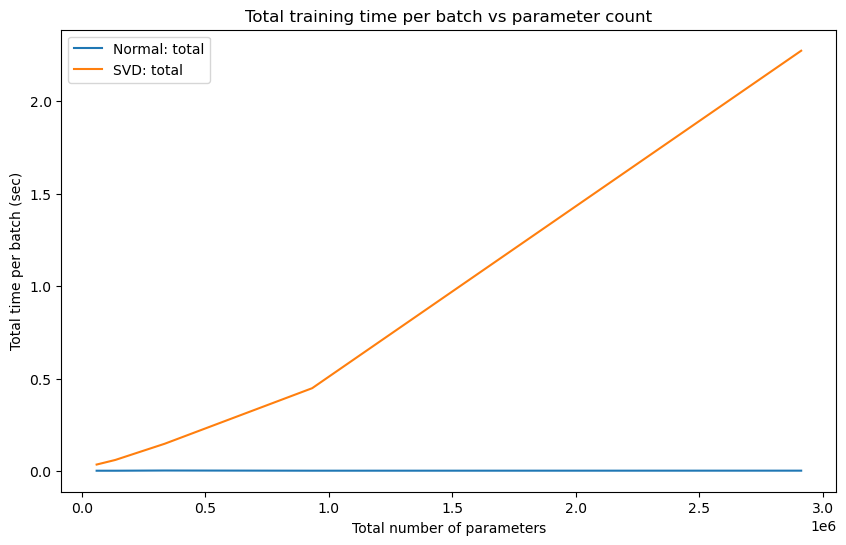

In [15]:
# Plot breakdowns by total number of parameters
num_params_list = [r["num_params"] for r in results]
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for k in ["forward", "backward", "step"]:
    plt.plot(num_params_list, [r["normal"][k]["mean"] for r in results], label=f"Normal: {k}")
or k in ["jacobian", "update", "apply"]:
    plt.plot(num_params_list, [r["svd"][k]["mean"] for r in results], label=f"SVD: {k}")
plt.xlabel("Total number of parameters")
plt.ylabel("Mean time per batch (sec)")
plt.legend()
plt.title("Training time scaling by parameter count")
plt.show()

# Plot total time per batch for each method
plt.figure(figsize=(10,6))
plt.plot(num_params_list, [sum(r["normal"][k]["mean"] for k in ["forward", "backward", "step"]) for r in results], label="Normal: total")
plt.plot(num_params_list, [sum(r["svd"][k]["mean"] for k in ["jacobian", "update", "apply"]) for r in results], label="SVD: total")
plt.xlabel("Total number of parameters")
plt.ylabel("Total time per batch (sec)")
plt.yscale('log')
plt.legend()
plt.title("Total training time per batch vs parameter count")
plt.show()


# test with microbatching

In [10]:
model_svd = tsvd.MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size).to(device)
loss_fn = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

microbatch_size = 4 
lr_svd = 0.5
k_svd = 150 // microbatch_size
rtol = 1e-3
opt_svd = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)
fmodel_svd = tsvd.FunctionalModelJac(model_svd, loss_lambda, opt_svd,sub_batch_size=microbatch_size)

num_epochs = 5
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

losses_svd = defaultdict(list)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses, batch_info = fmodel_svd.train_step(batch)
            #gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
            #update, extra_info = opt_svd.compute_update(gradients, losses)
            #params_svd = params_svd + update
            #fmodel_svd.params = params_svd
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = fmodel_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

with open(f"mnist_svd_losses_microbatch{microbatch_size}.pt", "w") as f:
    json.dump(losses_svd, f)

Epoch 1/5


  0%|          | 0/59 [00:00<?, ?it/s]

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
100%|██████████| 59/59 [00:13<00:00,  4.42it/s]


Epoch 2/5


100%|██████████| 59/59 [00:11<00:00,  5.14it/s]


...

100%|██████████| 59/59 [00:11<00:00,  5.11it/s]


Epoch 4/5


100%|██████████| 59/59 [00:11<00:00,  5.14it/s]


Epoch 5/5


100%|██████████| 59/59 [00:11<00:00,  5.09it/s]


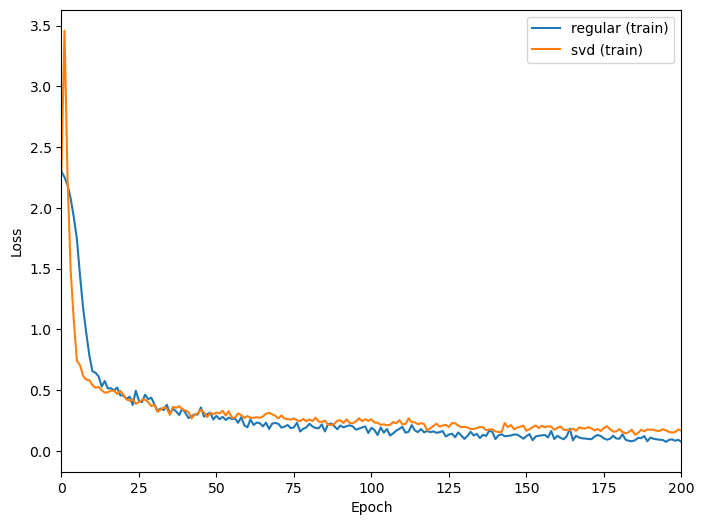

In [11]:
with open(f"mnist_svd_losses_microbatch{microbatch_size}.pt", "r") as f:
    losses_svd = json.load(f)

plt.figure(figsize=(8,6))
#plt.plot(losses_direct['val'], label='regular (val)',color="C0")
#plt.plot(losses_svd['val'], label='svd (val)',color="C1")
plt.plot(losses_direct['train_batch'], label='regular (train)',color="C0")
plt.plot(losses_svd['train_batch'], label='svd (train)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.xlim(0,200)
plt.legend()
plt.show()

# try random parameters

In [12]:
model_svd = tsvd.MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size).to(device)
loss_fn = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

param_fraction = 0.5
lr_svd = 0.5
k_svd = 150
rtol = 1e-3
opt_svd = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)
fmodel_svd = tsvd.FunctionalModelJac(model_svd, loss_lambda, opt_svd,param_fraction=param_fraction)

num_epochs = 5
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

losses_svd = defaultdict(list)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses, batch_info = fmodel_svd.train_step(batch)
            #gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
            #update, extra_info = opt_svd.compute_update(gradients, losses)
            #params_svd = params_svd + update
            #fmodel_svd.params = params_svd
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = fmodel_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

with open(f"mnist_svd_losses_param_fraction{param_fraction}.pt", "w") as f:
    json.dump(losses_svd, f)

Epoch 1/5


100%|██████████| 59/59 [00:18<00:00,  3.19it/s]


Epoch 2/5


100%|██████████| 59/59 [00:17<00:00,  3.40it/s]


Epoch 3/5


100%|██████████| 59/59 [00:17<00:00,  3.35it/s]


Epoch 4/5


100%|██████████| 59/59 [00:17<00:00,  3.40it/s]


Epoch 5/5


100%|██████████| 59/59 [00:17<00:00,  3.41it/s]


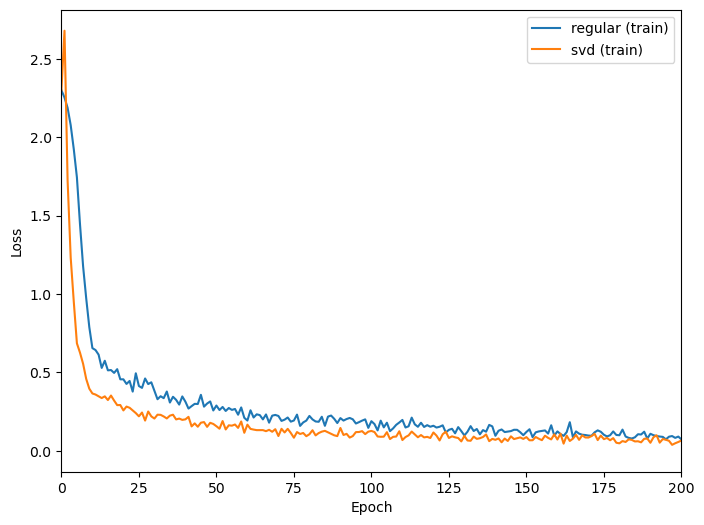

In [13]:
with open(f"mnist_svd_losses_param_fraction{param_fraction}.pt", "r") as f:
    losses_svd = json.load(f)

plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_batch'], label='regular (train)',color="C0")
plt.plot(losses_svd['train_batch'], label='svd (train)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.xlim(0,200)
plt.legend()
plt.show()

In [14]:
model_svd = tsvd.MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size).to(device)
loss_fn = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

param_fraction = 0.1
lr_svd = 0.5
k_svd = 150
rtol = 1e-3
opt_svd = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)
fmodel_svd = tsvd.FunctionalModelJac(model_svd, loss_lambda, opt_svd,param_fraction=param_fraction)

num_epochs = 5
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

losses_svd = defaultdict(list)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses, batch_info = fmodel_svd.train_step(batch)
            #gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
            #update, extra_info = opt_svd.compute_update(gradients, losses)
            #params_svd = params_svd + update
            #fmodel_svd.params = params_svd
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = fmodel_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

with open(f"mnist_svd_losses_param_fraction{param_fraction}.pt", "w") as f:
    json.dump(losses_svd, f)

Epoch 1/5


100%|██████████| 59/59 [00:15<00:00,  3.75it/s]


Epoch 2/5


100%|██████████| 59/59 [00:15<00:00,  3.78it/s]


Epoch 3/5


100%|██████████| 59/59 [00:15<00:00,  3.79it/s]


Epoch 4/5


100%|██████████| 59/59 [00:15<00:00,  3.78it/s]


Epoch 5/5


100%|██████████| 59/59 [00:15<00:00,  3.75it/s]


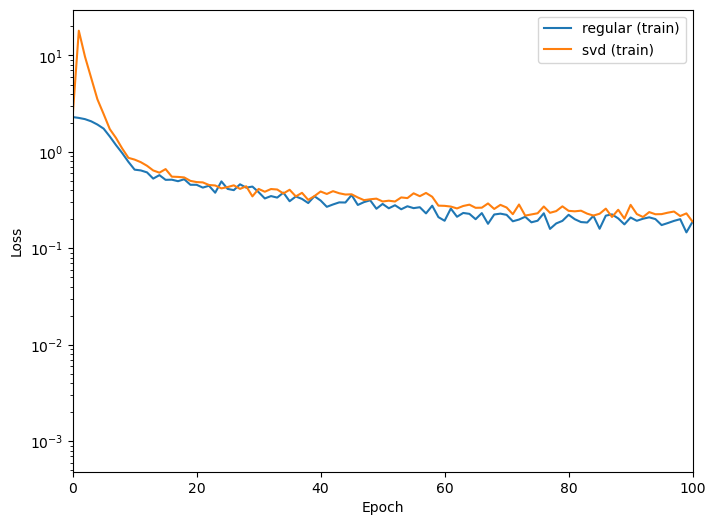

In [21]:
with open(f"mnist_svd_losses_param_fraction{param_fraction}.pt", "r") as f:
    losses_svd = json.load(f)

plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_batch'], label='regular (train)',color="C0")
plt.plot(losses_svd['train_batch'], label='svd (train)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.xlim(0,100)
plt.legend()
plt.show()